# Viwanda Price Mining

Self-contained notebook for scraping Viwanda wholesale price PDFs without saving PDF files. It streams each PDF in memory and writes only `documents.json`, `prices.json`, and `prices.csv` under `notebooks/mining/data/`.

### Step 1: Setup

This cell loads the libraries used for HTTP requests, HTML parsing, in-memory PDF reading, table extraction, and CSV/JSON output. It also resolves the project root so the notebook works whether it is opened from the project root or from `notebooks/mining`.

In [82]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
from urllib.parse import urljoin
import csv
import json
import re
import sys
import time

import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
import requests
from bs4 import BeautifulSoup

# Resolve the backend project root. Jupyter can start from different folders,
# so we look for manage.py as the anchor file.
ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "manage.py").exists():
    ROOT_DIR = Path.cwd().parents[1]

# Keep notebook outputs separate from Django application code.
MINING_DIR = ROOT_DIR / "notebooks" / "mining"
DATA_DIR = MINING_DIR / "data"
DOCUMENTS_FILE = DATA_DIR / "documents.json"
PRICES_JSON = DATA_DIR / "prices.json"
PRICES_CSV = DATA_DIR / "prices.csv"

# Viwanda source page for domestic product price documents.
BASE_URL = "https://www.viwanda.go.tz"
LIST_URL = f"{BASE_URL}/documents/product-prices-domestic"
# A descriptive User-Agent is better than the default Python requests header.
HEADERS = {
    "User-Agent": "MarketPriceResearchCrawler/1.0 (notebook research)"
}

print(f"Python kernel: {sys.executable}")
print(f"Mining folder: {MINING_DIR}")

Python kernel: c:\Users\ISSAH\Desktop\Projects\DIT\fyp2026\fyp2026_backend\venv\Scripts\python.exe
Mining folder: c:\Users\ISSAH\Desktop\Projects\DIT\fyp2026\fyp2026_backend\notebooks\mining


### Config

`MAX_PAGES` controls how many Viwanda listing pages are scanned for PDF links. `LIMIT` controls how many collected PDFs are streamed and extracted. Keep both small while testing; set `LIMIT = None` for a full extraction run.

In [83]:
# Number of Viwanda listing pages to scan for document links.
MAX_PAGES = 1

# Number of PDFs to stream and extract. Use None to process all collected links.
LIMIT = 5

# Full run:
# MAX_PAGES = 46
# LIMIT = None

### Step 2: Helpers

These functions clean noisy PDF text, convert price strings into integers, extract report dates from English or Swahili month names, and turn each PDF table into normalized price records.

In [84]:
# Viwanda reports can use Swahili month names, so map them to month numbers.
MONTHS_SW = {
    "januari": "01",
    "februari": "02",
    "machi": "03",
    "aprili": "04",
    "mei": "05",
    "juni": "06",
    "julai": "07",
    "agost": "08",
    "agosti": "08",
    "septemba": "09",
    "oktoba": "10",
    "novemba": "11",
    "desemba": "12",
}

# Some older/newer titles use English month names.
MONTHS_EN = {
    "january": "01",
    "february": "02",
    "march": "03",
    "april": "04",
    "may": "05",
    "june": "06",
    "july": "07",
    "august": "08",
    "september": "09",
    "october": "10",
    "november": "11",
    "december": "12",
}

MONTHS = MONTHS_SW | MONTHS_EN

# Commodity order used by the Viwanda wholesale price reports when
# pdfplumber extracts only the table body and drops the visual header row.
DEFAULT_COMMODITIES = [
    "Maize (Mahindi)",
    "Rice (Mchele)",
    "Sorghum (Mtama)",
    "Bulrush Millet (Uwele)",
    "Finger Millet (Ulezi)",
    "Wheat Grain (Ngano)",
    "Beans (Maharage)",
    "Irish Potatoes (Viazi Mviringo)",
]


def clean_text(value):
    # PDF table cells often contain newlines and repeated spacing.
    if value is None:
        return ""
    return re.sub(r"\s+", " ", str(value).replace("\n", " ")).strip()


def clean_price(value):
    # Prices are usually formatted with commas/spaces; keep digits only.
    text = clean_text(value).upper()
    if not text or text == "NA":
        return None

    digits = re.sub(r"[^\d]", "", text)
    if not digits:
        return None

    return int(digits)


def looks_like_price(value):
    text = clean_text(value).upper()
    return text == "NA" or bool(re.search(r"\d", text))


def extract_date(text):
    # Look for dates like "24 Juni, 2026", "05 ,Agost ,2026", or "24th June, 2026".
    normalized = clean_text(text).lower()
    month_pattern = "|".join(sorted(MONTHS, key=len, reverse=True))
    pattern = rf"(\d{{1,2}})(?:st|nd|rd|th)?\s*,?\s*({month_pattern})\s*,?\s*(\d{{4}})"
    match = re.search(pattern, normalized, flags=re.IGNORECASE)
    if not match:
        return None

    day, month_name, year = match.groups()
    return f"{year}-{MONTHS[month_name.lower()]}-{int(day):02d}"


def commodity_columns(header_row):
    # Each commodity usually has two adjacent columns: minimum and maximum price.
    columns = []
    last_commodity = ""

    for index, value in enumerate(header_row[2:], start=2):
        text = clean_text(value)
        if text:
            last_commodity = text

        if index % 2 == 0 and last_commodity:
            columns.append((index, last_commodity))

    return columns


def default_commodity_columns(row):
    # Body-only tables start with region/market, then min/max price pairs.
    price_columns = list(range(2, len(row) - 1, 2))
    return [
        (column_index, commodity)
        for column_index, commodity in zip(price_columns, DEFAULT_COMMODITIES)
    ]


def extract_table_prices(table, source_name, document_date, page_number):
    # Skip tiny or malformed tables that cannot contain the expected data.
    if len(table) < 4:
        return []

    # Some Viwanda PDFs return only body rows from pdfplumber. In that case,
    # row 0 already contains region, market, and prices, not header labels.
    first_row = table[0]
    body_only_table = len(first_row) > 3 and looks_like_price(first_row[2])

    if body_only_table:
        title = ""
        columns = default_commodity_columns(first_row)
        data_rows = enumerate(table, start=1)
    else:
        # Older extractions include a title row, commodity header row, and unit row.
        title = clean_text(table[0][0] if table[0] else "")
        header_row = table[1]
        columns = commodity_columns(header_row)
        data_rows = enumerate(table[3:], start=4)
    records = []

    for row_number, row in data_rows:
        if len(row) < 4:
            continue

        region = clean_text(row[0])
        market = clean_text(row[1])
        if not region or not market:
            continue

        for min_index, commodity in columns:
            max_index = min_index + 1
            if max_index >= len(row):
                continue

            min_price = clean_price(row[min_index])
            max_price = clean_price(row[max_index])
            if min_price is None and max_price is None:
                continue

            records.append(
                {
                    "date": document_date,
                    "region": region,
                    "market": market,
                    "commodity": commodity,
                    "min_price": min_price,
                    "max_price": max_price,
                    "unit": "TZS per 100kg",
                    "source_pdf": source_name,
                    "page": page_number,
                    "table_title": title,
                    "row_number": row_number,
                }
            )

    return records

### Scraping

These helpers read Viwanda listing pages, store only the PDF metadata in `documents.json`, and fetch each PDF as bytes when needed. The PDF bytes are passed directly to `pdfplumber`, so no PDF files are written to disk.

In [85]:
def load_documents(documents_file=DOCUMENTS_FILE):
    # Reuse previously collected links when doing repeated experiments.
    if not documents_file.exists():
        return []

    with documents_file.open("r", encoding="utf-8") as file:
        documents = json.load(file)

    if not isinstance(documents, list):
        raise ValueError(f"Expected a list of documents in {documents_file}")

    return documents


def save_documents(documents, output_file=DOCUMENTS_FILE):
    # Save only lightweight metadata, not the PDF files themselves.
    output_file.parent.mkdir(parents=True, exist_ok=True)
    output_file.write_text(
        json.dumps(documents, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )


def collect_documents(max_pages=46):
    # Fresh collection follows the visible page order from page 1 downward.
    documents = []
    seen_urls = set()

    with requests.Session() as session:
        session.headers.update(HEADERS)

        for page in range(1, max_pages + 1):
            url = f"{LIST_URL}?page={page}"
            print(f"Reading page {page}: {url}")

            try:
                response = session.get(url, timeout=30)
                response.raise_for_status()
            except Exception as error:
                print(f"Failed to read page {page}: {error}")
                break

            # Viwanda document links point into /uploads/documents/.
            soup = BeautifulSoup(response.text, "html.parser")
            links = soup.select('a[href*="/uploads/documents/"]')
            if not links:
                break

            for link in links:
                href = link.get("href")
                if not href:
                    continue

                document_url = urljoin(BASE_URL, href)
                if document_url in seen_urls:
                    continue

                seen_urls.add(document_url)
                # Keep links in the same order they appear on the Viwanda page.
                documents.append(
                    {
                        "title": link.get_text(" ", strip=True),
                        "url": document_url,
                        "listing_page": str(page),
                    }
                )

            # Small pause to avoid hammering the public website during full runs.
            time.sleep(1)

    return documents


def fetch_pdf_bytes(session, document_url):
    # Fetch the PDF into memory only. Nothing is saved to disk here.
    last_error = None
    for attempt in range(1, 4):
        try:
            response = session.get(document_url, timeout=60)
            response.raise_for_status()
            break
        except requests.RequestException as error:
            last_error = error
            if attempt == 3:
                raise
            time.sleep(attempt)

    content_type = response.headers.get("Content-Type", "").lower()
    if "pdf" not in content_type and not response.content.startswith(b"%PDF"):
        raise ValueError(f"URL did not return a PDF: {document_url}")

    return response.content


def extract_pdf_bytes(pdf_bytes, source_name):
    # BytesIO lets pdfplumber read the downloaded bytes as if they were a file.
    records = []

    with pdfplumber.open(BytesIO(pdf_bytes)) as pdf:
        first_text = pdf.pages[0].extract_text() if pdf.pages else ""
        document_date = extract_date(first_text or source_name)

        for page_number, page in enumerate(pdf.pages, start=1):
            for table in page.extract_tables():
                records.extend(
                    extract_table_prices(table, source_name, document_date, page_number)
                )

    return records

### Pipeline

This cell defines the output schema and the main `mine_viwanda` function. The function optionally refreshes document links, streams selected PDFs in memory, extracts price records, and saves the final structured datasets.

In [86]:
# Fixed column order for CSV output. Keeping this explicit makes the dataset stable.
PRICE_FIELDNAMES = [
    "date",
    "region",
    "market",
    "commodity",
    "min_price",
    "max_price",
    "unit",
    "source_pdf",
    "page",
    "table_title",
    "row_number",
]


def write_json(records, output_file=PRICES_JSON):
    # JSON preserves full records and is convenient for programmatic reuse.
    output_file.parent.mkdir(parents=True, exist_ok=True)
    output_file.write_text(
        json.dumps(records, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )


def write_csv(records, output_file=PRICES_CSV):
    # CSV is easier to inspect in notebooks, Excel, and pandas.
    output_file.parent.mkdir(parents=True, exist_ok=True)

    with output_file.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=PRICE_FIELDNAMES)
        writer.writeheader()
        writer.writerows(records)


def mine_viwanda(max_pages=46, limit=None, skip_collect=False, skip_extract=False):
    # Main notebook pipeline. PDF files are never written to disk.
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if skip_collect:
        # Useful when documents.json already exists and you are tuning extraction logic.
        documents = load_documents()
    else:
        documents = collect_documents(max_pages=max_pages)
        save_documents(documents)

    records = []
    if not skip_extract:
        # LIMIT keeps test runs fast; None processes every collected document.
        selected_documents = documents[:limit] if limit else documents

        with requests.Session() as session:
            session.headers.update(HEADERS)

            for index, document in enumerate(selected_documents, start=1):
                document_url = document.get("url")
                title = document.get("title") or document_url or f"document-{index}"

                if not document_url:
                    print(f"Skipping document {index}: missing url")
                    continue

                try:
                    # Fetch, parse, and discard the PDF bytes after extraction.
                    pdf_bytes = fetch_pdf_bytes(session, document_url)
                    records.extend(extract_pdf_bytes(pdf_bytes, title))
                except Exception as error:
                    print(f"Failed to mine {title}: {error}")
                    continue

                print(f"Mined {index}/{len(selected_documents)}: {title}")

        write_json(records)
        write_csv(records)

    return {
        "documents": len(documents),
        "price_records": len(records),
        "documents_file": str(DOCUMENTS_FILE),
        "prices_json": str(PRICES_JSON),
        "prices_csv": str(PRICES_CSV),
    }

### Step 3: Run

Run this cell after changing `MAX_PAGES` and `LIMIT`. During testing, keep `LIMIT` low to verify extraction quickly. The returned summary shows how many links were known and how many price records were extracted.

In [87]:
# This is the main execution cell for the notebook.
summary = mine_viwanda(
    max_pages=MAX_PAGES,
    limit=LIMIT,
)

summary

Reading page 1: https://www.viwanda.go.tz/documents/product-prices-domestic?page=1
Mined 1/5: Bei ya bidhaa th  10 ,Agost ,2026 Imewekwa 10th Aug 2026
Mined 2/5: Bei ya bidhaa th  07 Agost  ,2026 Imewekwa 07th Aug 2026
Mined 3/5: Bei ya bidhaa th  05 ,Agost ,2026 Imewekwa 05th Aug 2026
Mined 4/5: Bei ya bidhaa th  03 ,Agost ,2026 Imewekwa 03rd Aug 2026
Mined 5/5: Bei ya bidhaa th  31 Julai ,2026 Imewekwa 31st Jul 2026


{'documents': 16,
 'price_records': 1190,
 'documents_file': 'c:\\Users\\ISSAH\\Desktop\\Projects\\DIT\\fyp2026\\fyp2026_backend\\notebooks\\mining\\data\\documents.json',
 'prices_json': 'c:\\Users\\ISSAH\\Desktop\\Projects\\DIT\\fyp2026\\fyp2026_backend\\notebooks\\mining\\data\\prices.json',
 'prices_csv': 'c:\\Users\\ISSAH\\Desktop\\Projects\\DIT\\fyp2026\\fyp2026_backend\\notebooks\\mining\\data\\prices.csv'}

### Step 4: Inspect

This cell reads the generated CSV into pandas so you can inspect the first rows, confirm column types, and start cleaning or analysis work.

In [88]:
# Load the CSV only after the mining pipeline has produced it.
if PRICES_CSV.exists():
    prices = pd.read_csv(PRICES_CSV)
    display(prices.head())
    display(prices.info())
else:
    print(f"No extracted prices found yet: {PRICES_CSV}")

,date,region,market,commodity,min_price,max_price,unit,source_pdf,page,table_title,row_number
0,2026-08-10,Dar es salaam,Ilala,Maize (Mahindi),90000,100000,TZS per 100kg,"Bei ya bidhaa th 10 ,Agost ,2026 Imewekwa 10t...",1,NaN,1
1,2026-08-10,Dar es salaam,Ilala,Rice (Mchele),230000,320000,TZS per 100kg,"Bei ya bidhaa th 10 ,Agost ,2026 Imewekwa 10t...",1,NaN,1
2,2026-08-10,Dar es salaam,Ilala,Sorghum (Mtama),110000,130000,TZS per 100kg,"Bei ya bidhaa th 10 ,Agost ,2026 Imewekwa 10t...",1,NaN,1
3,2026-08-10,Dar es salaam,Ilala,Bulrush Millet (Uwele),100000,130000,TZS per 100kg,"Bei ya bidhaa th 10 ,Agost ,2026 Imewekwa 10t...",1,NaN,1
4,2026-08-10,Dar es salaam,Ilala,Finger Millet (Ulezi),180000,180000,TZS per 100kg,"Bei ya bidhaa th 10 ,Agost ,2026 Imewekwa 10t...",1,NaN,1


<class 'pandas.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         476 non-null    str    
 1   region       1190 non-null   str    
 2   market       1190 non-null   str    
 3   commodity    1190 non-null   str    
 4   min_price    1190 non-null   int64  
 5   max_price    1190 non-null   int64  
 6   unit         1190 non-null   str    
 7   source_pdf   1190 non-null   str    
 8   page         1190 non-null   int64  
 9   table_title  0 non-null      float64
 10  row_number   1190 non-null   int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 102.4 KB


None

### Visual Analysis

These cells summarize missing values, show any undated records, and plot simple distributions so extraction problems are easy to spot.

In [89]:
# Null count and null percentage for each column.
null_summary = (
    prices.isna()
    .sum()
    .rename("null_count")
    .to_frame()
)
null_summary["null_percent"] = (null_summary["null_count"] / len(prices) * 100).round(2)
null_summary.sort_values("null_count", ascending=False)

,null_count,null_percent
table_title,1190,100.0
date,714,60.0
region,0,0.0
market,0,0.0
commodity,0,0.0
max_price,0,0.0
min_price,0,0.0
unit,0,0.0
source_pdf,0,0.0
page,0,0.0


In [90]:
# Show records that still failed date extraction.
undated = prices[prices["date"].isna()].copy()
print(f"Undated records: {len(undated)}")

if len(undated):
    display(
        undated[["source_pdf", "region", "market", "commodity", "min_price", "max_price"]]
        .drop_duplicates()
        .head(30)
    )

Undated records: 714


,source_pdf,region,market,commodity,min_price,max_price
238,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es salaam,Ilala,Maize (Mahindi),90000,100000
239,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es salaam,Ilala,Rice (Mchele),230000,320000
240,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es salaam,Ilala,Sorghum (Mtama),110000,130000
241,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es salaam,Ilala,Bulrush Millet (Uwele),100000,130000
242,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es salaam,Ilala,Finger Millet (Ulezi),180000,180000
243,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es salaam,Ilala,Beans (Maharage),320000,350000
244,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es salaam,Ilala,Irish Potatoes (Viazi Mviringo),90000,100000
245,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es saalam,Tandika,Maize (Mahindi),100000,110000
246,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es saalam,Tandika,Rice (Mchele),220000,300000
247,"Bei ya bidhaa th 07 Agost ,2026 Imewekwa 07t...",Dar es saalam,Tandika,Sorghum (Mtama),120000,140000


In [91]:
# Convert date and price columns to analysis-friendly dtypes.
analysis = prices.copy()
analysis["date"] = pd.to_datetime(analysis["date"], errors="coerce")
analysis["min_price"] = pd.to_numeric(analysis["min_price"], errors="coerce")
analysis["max_price"] = pd.to_numeric(analysis["max_price"], errors="coerce")
analysis["avg_price"] = analysis[["min_price", "max_price"]].mean(axis=1)

display(analysis[["date", "region", "market", "commodity", "avg_price"]].head())

,date,region,market,commodity,avg_price
0,2026-08-10,Dar es salaam,Ilala,Maize (Mahindi),95000.0
1,2026-08-10,Dar es salaam,Ilala,Rice (Mchele),275000.0
2,2026-08-10,Dar es salaam,Ilala,Sorghum (Mtama),120000.0
3,2026-08-10,Dar es salaam,Ilala,Bulrush Millet (Uwele),115000.0
4,2026-08-10,Dar es salaam,Ilala,Finger Millet (Ulezi),180000.0


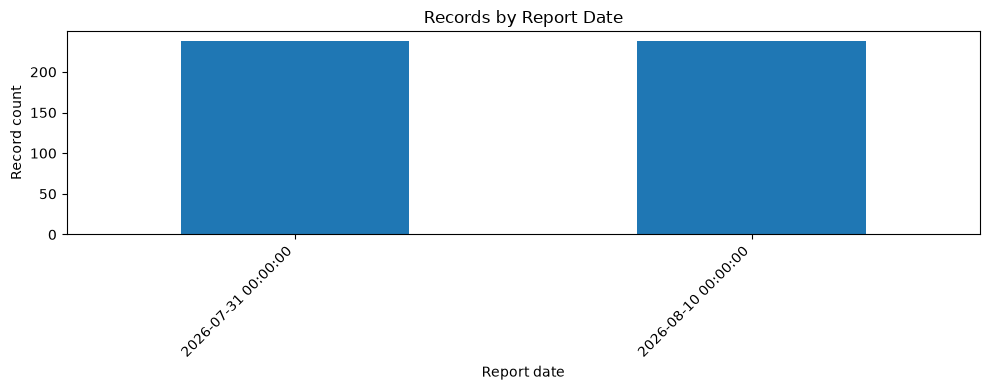

In [92]:
# Graph 1: records extracted per report date.
records_by_date = analysis.dropna(subset=["date"]).groupby("date").size()

ax = records_by_date.plot(kind="bar", figsize=(10, 4), title="Records by Report Date")
ax.set_xlabel("Report date")
ax.set_ylabel("Record count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

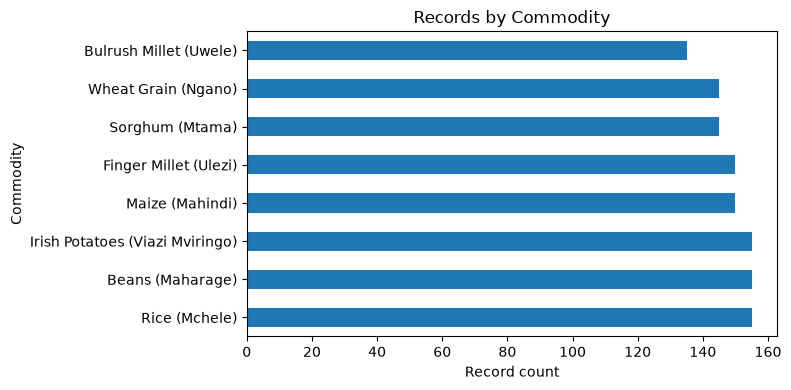

In [93]:
# Graph 2: number of records by commodity.
ax = analysis["commodity"].value_counts().plot(
    kind="barh",
    figsize=(8, 4),
    title="Records by Commodity",
)
ax.set_xlabel("Record count")
ax.set_ylabel("Commodity")
plt.tight_layout()
plt.show()

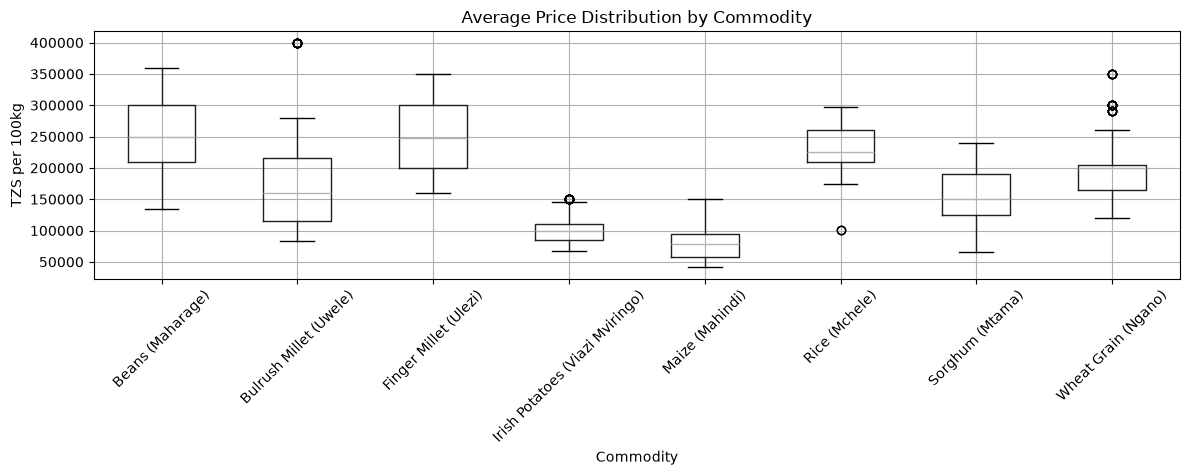

In [94]:
# Graph 3: average price distribution by commodity.
ax = analysis.boxplot(column="avg_price", by="commodity", figsize=(12, 5), rot=45)
ax.set_title("Average Price Distribution by Commodity")
ax.set_xlabel("Commodity")
ax.set_ylabel("TZS per 100kg")
plt.suptitle("")
plt.tight_layout()
plt.show()

### Reuse Links

Run this cell when `documents.json` already exists and you only want to stream and re-extract those links. This is useful when you are editing the parsing helpers and do not want to scan the listing pages again.

In [95]:
# summary = mine_viwanda(
#     limit=LIMIT,
#     skip_collect=True,
# )
#
# summary